# 💻 Week 7 Practice - Solutions

## 1️⃣ Load the Data

We first load the dataset from a CSV file into a pandas DataFrame. Each row contains a text `review` and a `label` (e.g. positive/negative). We extract both columns as plain Python lists - this is the format most sklearn functions expect.

In [1]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

df = pd.read_csv("StreamingMediaReviews.csv")
print(df.head())  # preview the first few rows

# Extract the text reviews and their corresponding labels as lists
reviews = df['review'].tolist()
labels  = df['label'].tolist()

print(reviews[:3])                              # sanity-check: show first 3 reviews
print(labels[:3])                               # sanity-check: show first 3 labels
print("Lengths match:", len(reviews) == len(labels))  # must be True before we proceed

                                              review                label
0  A okay song. do not advice you to skip this. M...        inappropriate
1  Absolutely impressive video clip. would not li...  positive evaluation
2  utterly short duet. makes me think of the ques...              neutral
3  definitely idiotic duet. Strongly recommend yo...        inappropriate
4  Absolutely fun video. Brings me back to the qu...  positive evaluation
['A okay song. do not advice you to skip this. Makes me reflect on childhood memories', 'Absolutely impressive video clip. would not like to come across it again. urge recommend you to see this', 'utterly short duet. makes me think of the question of who we are.']
['inappropriate', 'positive evaluation', 'neutral']
Lengths match: True


## 2️⃣ Plot Label Distribution

Before training any model it is important to check whether the classes are balanced. A heavily imbalanced dataset (e.g. 95% positive, 5% negative) can make accuracy misleading and may require special handling. `Counter` tallies how many times each label appears, and we visualise the result as a bar chart.

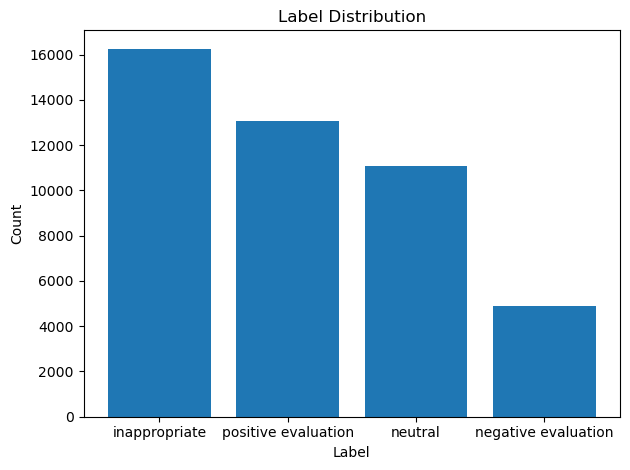

In [2]:
counts = Counter(labels)  # count occurrences of each unique label

plt.bar(counts.keys(), counts.values())  # one bar per label class
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 3️⃣ Train / Test Split

We split the data into a **training set** (80%) used to fit the model, and a **test set** (20%) held back to evaluate how well the model generalises to unseen examples. `random_state=42` makes the split reproducible - everyone running this notebook gets the same split.

In [3]:
from sklearn.model_selection import train_test_split

# Split reviews and labels together so they stay aligned
reviews_train, reviews_test, y_train, y_test = train_test_split(
    reviews, labels,
    test_size=0.2,      # 20% of data goes to the test set
    random_state=42     # fixed seed for reproducibility
)

print("Train:", len(reviews_train), "| Test:", len(reviews_test))

Train: 36220 | Test: 9055


## 4️⃣ Vectorize Text — CountVectorizer

Machine learning models cannot work with raw strings. `CountVectorizer` converts each review into a **bag-of-words** vector: a row of counts showing how many times each word in the vocabulary appears in that review.

Key rule: **fit only on training data**, then transform both sets using that same vocabulary. Fitting on the test set would leak information and give an over-optimistic evaluation.

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english')  # ignore common words like "the", "is", "and"

# fit_transform: builds vocabulary from training data AND converts to count matrix
X_train = cv.fit_transform(reviews_train)

# transform only: reuses the training vocabulary (no re-fitting on test data)
X_test  = cv.transform(reviews_test)

# Shape is (number of reviews, number of unique words in vocabulary)
print("Shape:", X_train.shape)

Shape: (36220, 91)


## 5️⃣ Train a Naive Bayes Classifier

**Multinomial Naive Bayes** is a classic and fast algorithm for text classification. It works by learning which words are most associated with each label (using probability estimates from the training counts), then predicts the most likely label for new reviews. It is called "naive" because it assumes each word is independent of the others - a simplification that still works surprisingly well in practice.

In [5]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()          # instantiate the classifier
nb.fit(X_train, y_train)      # train: learn word probabilities per class

# Predict labels for the held-out test reviews
y_pred = nb.predict(X_test)

print("First 5 predictions:", y_pred[:5])  # quick sanity check

First 5 predictions: ['neutral' 'neutral' 'neutral' 'neutral' 'positive evaluation']


## 6️⃣ Evaluate: Classification Report

We compare our predictions (`y_pred`) against the true labels (`y_test`). The classification report gives per-class metrics:

| Metric | Meaning |
|--------|---------|
| **Precision** | Of all reviews predicted as class X, what fraction actually are X? |
| **Recall** | Of all reviews that are class X, what fraction did we correctly identify? |
| **F1-score** | Harmonic mean of precision and recall — a single balanced summary |
| **Support** | Number of true examples for each class in the test set |

In [6]:
from sklearn.metrics import classification_report

# y_test = true labels, y_pred = what the model predicted
print(classification_report(y_test, y_pred))

                     precision    recall  f1-score   support

      inappropriate       0.90      0.78      0.84      3290
negative evaluation       0.55      1.00      0.71      1025
            neutral       0.45      0.60      0.51      2165
positive evaluation       0.54      0.30      0.39      2575

           accuracy                           0.63      9055
          macro avg       0.61      0.67      0.61      9055
       weighted avg       0.65      0.63      0.62      9055



## 7️⃣ Level Up: TF-IDF + Logistic Regression

**TF-IDF** (Term Frequency–Inverse Document Frequency) is a smarter alternative to raw counts. Instead of just counting how often a word appears, it down-weights words that appear in almost every review (like "movie") and up-weights rarer, more discriminative words. This usually gives better features than plain counts.

**Logistic Regression** is a stronger classifier than Naive Bayes for text tasks: it learns a direct decision boundary rather than relying on independence assumptions. Together, TF-IDF + Logistic Regression is a strong and widely used baseline.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# TF-IDF vectorizer — same fit-on-train / transform-both pattern as CountVectorizer
tfidf = TfidfVectorizer(stop_words='english')
X_train_tf = tfidf.fit_transform(reviews_train)  # fit vocabulary + compute TF-IDF weights
X_test_tf  = tfidf.transform(reviews_test)        # apply same vocabulary to test set

# Logistic Regression — max_iter increased because the default (100) often fails to converge
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tf, y_train)      # train on TF-IDF features
y_pred_lr = lr.predict(X_test_tf)  # predict on test set

# Compare report against the Naive Bayes result above
print(classification_report(y_test, y_pred_lr))

                     precision    recall  f1-score   support

      inappropriate       0.95      0.79      0.86      3290
negative evaluation       0.55      0.89      0.68      1025
            neutral       0.45      0.14      0.22      2165
positive evaluation       0.54      0.84      0.66      2575

           accuracy                           0.66      9055
          macro avg       0.62      0.66      0.60      9055
       weighted avg       0.67      0.66      0.63      9055

